<a href="https://colab.research.google.com/github/Selvapriya05/Selvapriya-Codeboosters-2026/blob/main/Day_5/Day_5_Miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [ ]:
df = pd.read_csv("student_performance.csv")

print(df.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [ ]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())


print(df.isnull().sum())

(30, 13)
Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int

In [ ]:
conn = sqlite3.connect("student.db")

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data stored successfully")

#query1
query = """
SELECT department,
AVG(programming_score) as avg_programming
FROM students
GROUP BY department
"""
pd.read_sql(query, conn)

#query2
query = """
SELECT name,programming_score
FROM students
ORDER BY programming_score DESC
LIMIT 5
"""

pd.read_sql(query, conn)

#query3
query = """
SELECT department,
AVG(attendance_percentage) as avg_attendance
FROM students
GROUP BY department
"""

pd.read_sql(query, conn)

#query4
query = """
SELECT name,attendance_percentage
FROM students
WHERE attendance_percentage > 90
"""

pd.read_sql(query, conn)

#query5
query = """
SELECT department,
COUNT(*) as total_students
FROM students
GROUP BY department
"""

pd.read_sql(query, conn)

Data stored successfully


,department,total_students
0,Civil,5
1,Computer Science,13
2,Electronics,6
3,Mechanical,6


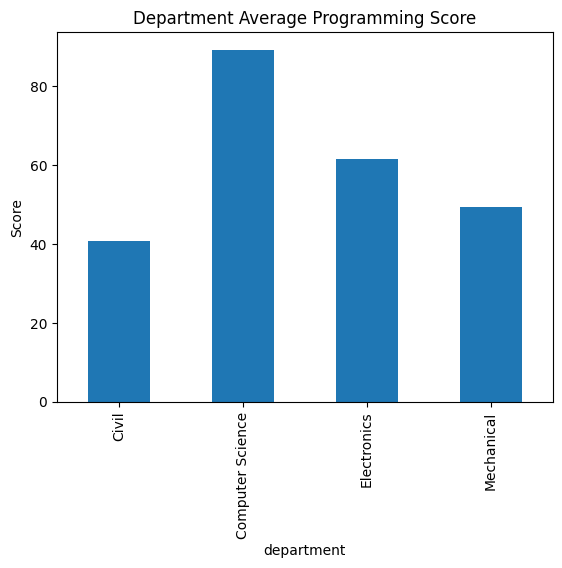

In [ ]:
#Visualization

#Chart 1: Department Average Programming Score

dept_avg = df.groupby("department")["programming_score"].mean()

dept_avg.plot(kind="bar")

plt.title("Department Average Programming Score")
plt.ylabel("Score")
plt.show()


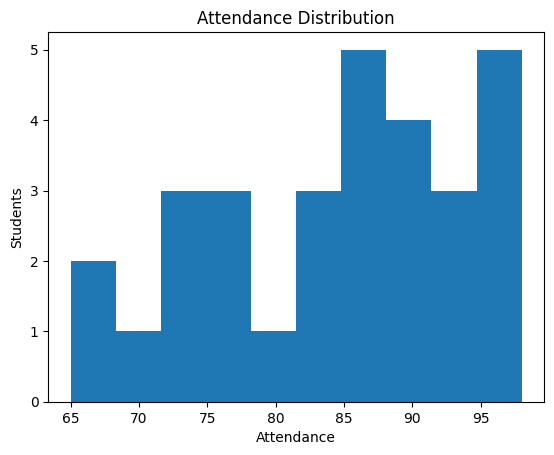

In [ ]:
#Chart 2: Attendance Distribution

plt.hist(df["attendance_percentage"])

plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Students")

plt.show()

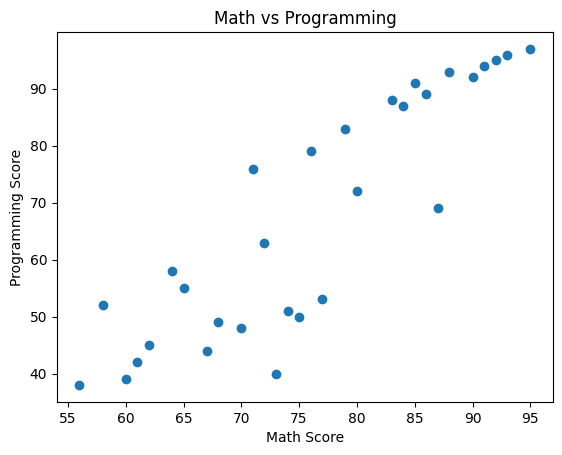

In [ ]:
#Chart 3: Math vs Programming Score

plt.scatter(
    df["math_score"],
    df["programming_score"]
)

plt.xlabel("Math Score")
plt.ylabel("Programming Score")
plt.title("Math vs Programming")

plt.show()

In [ ]:
#Machine Learning

#Predict Programming Score

#Features:

X = df[
[
"math_score",
"science_score",
"english_score",
"attendance_percentage"
]
]

y = df["programming_score"]

#Split Data

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Train Random Forest

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

#Prediction

predictions = model.predict(X_test)

print(predictions)

#Accuracy

mae = mean_absolute_error(y_test,predictions)

r2 = r2_score(y_test,predictions)

print("MAE:",mae)
print("R2 Score:",r2)

#Predict New Student

new_student = [[85,80,75,90]]

pred = model.predict(new_student)

print("Predicted Programming Score:",pred[0])

[50.71 90.92 73.76 92.94 48.4  94.82]
MAE: 10.151666666666669
R2 Score: 0.6429334636216426
Predicted Programming Score: 88.27


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
#Business Summary Insights

print("BUSINESS INSIGHTS")

print()

print("1. Computer Science students have highest programming performance.")

print("2. Students with higher attendance generally score better.")

print("3. Math score shows positive relation with programming score.")

print("4. Attendance above 90% improves overall performance.")

print("5. Random Forest model can predict programming score effectively.")

BUSINESS INSIGHTS

1. Computer Science students have highest programming performance.
2. Students with higher attendance generally score better.
3. Math score shows positive relation with programming score.
4. Attendance above 90% improves overall performance.
5. Random Forest model can predict programming score effectively.
